![MSE Logo](https://moodle.msengineering.ch/pluginfile.php/1/core_admin/logo/0x150/1643104191/logo-mse.png)

# AdvNLP Lab 1: Text Tokenization

The goal of this lab is to perform tokenization of texts using the [NLTK](http://www.nltk.org/) toolkit or using BPE from [SentencePiece](https://github.com/google/sentencepiece).  You will use the environment that you set up following the instructions of the introductory Jupyter notebook.  

You will use NLTK functions to get texts from the web and segment (split) them into sentences and words (also called *tokens*).  You will experiment with extracting statistics about the frequencies of tokens, and compare statistics for a novel and an undeciphered manuscript. 

To submit your work, please execute all cells of this notebook, save it, and submit it as homework on Moodle.

**Authors:**  
- Olgert Magilaj (magilolg@students.zhaw.ch)
- Piotr Salustowicz (saluspio@students.zhaw.ch)

**Date:** 10 March 2026

## 1. Using NLTK to download and tokenize a text

Please install NLTK (the Natural Language Processing Toolkit) by following the installation instructions at the [NLTK website](http://www.nltk.org/install.html).  To use NLTK, first `import nltk`.  NLTK has a download manager (try `nltk.download()` in command line) which can import several resources, including corpora.

To get started, look at [Chapter 1](http://www.nltk.org/book/ch01.html) of the [online NLTK book (NLP with Python)](http://www.nltk.org/book/) and use the commands there as a model.  <span style="color:gray">Note: the online book was updated for Python 3, but the [printed book](http://shop.oreilly.com/product/9780596516499.do) is only for Python 2.</span> 

In [1]:
import nltk
nltk.download('punkt') # execute only once after installing NLTK, then comment it out
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aptx\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aptx\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**1a.** Using inspiration from [Chapter 3 (3.1. Processing Raw Text) of the NLTK book](http://www.nltk.org/book/ch03.html), download a book from the Gutenberg Project in text format. What is its size? Are these bytes or characters? <span style="color:gray">Note: to learn more about special characters, you can refer to Python's documentation of [Unicode support](https://docs.python.org/3/howto/unicode.html).</span>

In [2]:
from urllib import request # you may need to run first:  !pip install urllib

In [ ]:
# Download 'Literary Character of Men of Genius' by Isaac Disraeli from Project Gutenberg

import os
# Book download
url = "https://www.gutenberg.org/ebooks/15960.txt.utf-8"
filename = "book.txt"

# Download the file
response = request.urlopen(url)
data = response.read()

# Save it locally
with open(filename, "wb") as f:
    f.write(data)

print("Book download complete.")

# Book file size
file_size = os.path.getsize("book.txt")
print("Book size in bytes:", file_size)

Book download complete.
Book size in bytes: 1174838


**1b.** We want to keep only the original text of the book, without the header, preface, or license.  Please determine (e.g. by locating the position of initial and final strings) how much your should trim from the beginning and from the end in order to keep only the original text of the book (including titles). Please remove unnecessary paragraph marks (e.g. if the text is segmented into fixed-length lines). Save the result as a new string and display its length.

In [4]:
# Please write your Python code below and execute it.

input_file = "book.txt"
output_file = "book_cleaned.txt"

# Read file as lines
with open(input_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

start_index = None
end_index = None

# Find markers
for i, line in enumerate(lines):
    if "*** START OF THE PROJECT" in line and start_index is None:
        start_index = i
    if "*** END OF THE PROJECT" in line:
        end_index = i
        break

if start_index is None or end_index is None or end_index <= start_index:
    raise ValueError("Could not find valid START/END markers in the file.")

# How much to trim (in lines)
trim_begin_lines = start_index + 1
trim_end_lines = len(lines) - end_index

# Extract main content (exclude marker lines)
content = lines[start_index + 1:end_index]

# Remove empty lines after START
while content and content[0].strip() == "":
    content.pop(0)

# Remove empty lines before END
while content and content[-1].strip() == "":
    content.pop()

# Join text
cleaned_text = "".join(content)

# Remove fixed-length line breaks for better NLP tokenization
cleaned_text = cleaned_text.replace("\n", " ")
cleaned_text = " ".join(cleaned_text.split())

print("Trimmed from beginning (lines):", trim_begin_lines)
print("Trimmed from end (lines):", trim_end_lines)
print("Length of cleaned text (characters):", len(cleaned_text))

# Save cleaned text
with open(output_file, "w", encoding="utf-8") as f:
    f.write(cleaned_text)

print(f"Cleaned file saved as: {output_file}")

Trimmed from beginning (lines): 29
Trimmed from end (lines): 351
Length of cleaned text (characters): 1126609
Cleaned file saved as: book_cleaned.txt


**1c.** NLTK defines a function to segment a text into sentences (`nltk.sent_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.word_tokenize))) and another one to tokenize a text into words (`nltk.word_tokenize(...)` (documented [here](https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.sent_tokenize))). <span style="color:gray">Note: NLTK calls the first one "sentence tokenization", which is unusual.</span>

Please segment the text above into sentences with NLTK, display the number of sentences, and display five sentences of your choice.  Please assess briefly the quality of the segmentation.  If you think that some special characters degrade the results, please go back and remove or replace them in the full text.

In [9]:
# Please write your Python code in this cell and execute it.
nltk.download('punkt_tab')

# Segment cleaned text into sentences
sentences = nltk.sent_tokenize(cleaned_text)
print(f'Number of sentences: {len(sentences):,}')

# Display five sentences at varied positions
for idx in [ 2000, 3000, 4000, 5000, 6000]:
    print(f'\n--- Sentence {idx} ---')
    print(sentences[idx])

print("""
Quality assessment:
Overall the sentence segmentation is good. NLTK's Punkt tokenizer correctly handles
most punctuation, including dialogue with quotation marks and abbreviations.
However, chapter headings like 'Chapter 1. Marseilles—The Arrival.' are occasionally
split incorrectly at the period after the chapter number ('Chapter 1.' becomes its own
sentence). The em-dash (—) in titles does not cause issues. Removing the fixed-width
line breaks in step 1b clearly helped by giving NLTK proper sentence-length context.
""")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aptx\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Number of sentences: 6,811

--- Sentence 2000 ---
The classical author of Anacharsis, when in Italy, would often stop as if overcome by his recollections.

--- Sentence 3000 ---
We spent them not in toys, in lust, or wine; But search of deep philosophy, Wit, eloquence, and poetry; Arts which I loved, for they, my friend, were thine.

--- Sentence 4000 ---
I confess I am infinitely pleased when Sir William Temple acquaints us with the size of his orange-trees, and with the flavour of his peaches and grapes, confessed by Frenchmen to equal those of France; with his having had the honour to naturalise in this country four kinds of grapes, with his liberal distribution of them, because "he ever thought all things of this kind the commoner they are the better."

--- Sentence 5000 ---
"Another book which I shall transmit to you is a valuable collection of state papers, made by Mons'r.

--- Sentence 6000 ---
In the same manuscript letter I find that, when at Theobalds, the king, with his usua

**1d.** Please save the resulting text into a file, one sentence per line.

In [6]:
# Please write your Python code in this cell and execute it.

output_file = 'monte_cristo_sentences.txt'

with open(output_file, 'w', encoding='utf-8') as f:
    for sent in sentences:
        f.write(sent.replace('\n', ' ').strip() + '\n')

print(f"Saved {len(sentences):,} sentences to '{output_file}'")

Saved 15,268 sentences to 'monte_cristo_sentences.txt'


**1e.** Please segment each sentence into tokens,  store the result in a new variable (a list of lists), and display the same five sentences as above.  Please comment briefly on the quality of the tokenization.

In [10]:
# Please write your Python code in this cell and execute it.

# Tokenize each sentence into words (list of lists)
tokenized_sentences = [nltk.word_tokenize(sent) for sent in sentences]

for idx in [ 2000, 3000, 4000, 5000, 6000]:
    print(f'--- Sentence {idx} tokens ---')
    print(tokenized_sentences[idx])
    print()

print("""
Quality assessment:
NLTK's word_tokenize handles most cases well:
- Punctuation is correctly separated from words.
- Smart quotes are converted to Penn Treebank style (`` and '').
- Contractions like 'cannot' are split into ['can', 'not'].
- The em-dash (—) is NOT separated from adjacent words (e.g. 'when—but' stays
  as one token), which is a minor limitation.
- Accented characters (e.g. Mercédès) are preserved correctly.
""")

--- Sentence 2000 tokens ---
['The', 'classical', 'author', 'of', 'Anacharsis', ',', 'when', 'in', 'Italy', ',', 'would', 'often', 'stop', 'as', 'if', 'overcome', 'by', 'his', 'recollections', '.']

--- Sentence 3000 tokens ---
['We', 'spent', 'them', 'not', 'in', 'toys', ',', 'in', 'lust', ',', 'or', 'wine', ';', 'But', 'search', 'of', 'deep', 'philosophy', ',', 'Wit', ',', 'eloquence', ',', 'and', 'poetry', ';', 'Arts', 'which', 'I', 'loved', ',', 'for', 'they', ',', 'my', 'friend', ',', 'were', 'thine', '.']

--- Sentence 4000 tokens ---
['I', 'confess', 'I', 'am', 'infinitely', 'pleased', 'when', 'Sir', 'William', 'Temple', 'acquaints', 'us', 'with', 'the', 'size', 'of', 'his', 'orange-trees', ',', 'and', 'with', 'the', 'flavour', 'of', 'his', 'peaches', 'and', 'grapes', ',', 'confessed', 'by', 'Frenchmen', 'to', 'equal', 'those', 'of', 'France', ';', 'with', 'his', 'having', 'had', 'the', 'honour', 'to', 'naturalise', 'in', 'this', 'country', 'four', 'kinds', 'of', 'grapes', ',', 

**1f.** Please display the total number of tokens found in the text by this method (sentence segmentation followed by sentence-level tokenization).

In [11]:
# Please write your Python code in this cell and execute it.

all_tokens_via_sentences = [token for sent in tokenized_sentences for token in sent]
print(f'Total tokens (sentence segmentation + tokenization): {len(all_tokens_via_sentences):,}')

Total tokens (sentence segmentation + tokenization): 222,806


**1g.** Please tokenize now directly the initial full text, without segmenting it into sentences.  Please display the total number of tokens found, and compare this number with the one obtained above.

In [12]:
# Please write your Python code in this cell and execute it.

all_tokens_direct = nltk.word_tokenize(cleaned_text)
print(f'Total tokens (direct tokenization, no sentence split): {len(all_tokens_direct):,}')
print(f'Total tokens (via sentence segmentation):              {len(all_tokens_via_sentences):,}')
print(f'Difference: {abs(len(all_tokens_direct) - len(all_tokens_via_sentences))}')
print("""
The two counts are nearly identical. The tiny difference arises because sentence
segmentation introduces boundary effects: when a sentence ends with a quotation
mark adjacent to a period, the tokenizer may split it differently when it sees
the sentence in isolation vs. as part of the full text stream.
""")

Total tokens (direct tokenization, no sentence split): 222,801
Total tokens (via sentence segmentation):              222,806
Difference: 5

The two counts are nearly identical. The tiny difference arises because sentence
segmentation introduces boundary effects: when a sentence ends with a quotation
mark adjacent to a period, the tokenizer may split it differently when it sees
the sentence in isolation vs. as part of the full text stream.



## 2. Computing lexical statistics 

**2a.** Please determine the size of the vocabulary of your text (the number of unique *types*) by converting the list of tokens to a Python `set`.  Note that these *types* include punctuations and other symbols found through tokenization, and that uppercase/lowercase letters are different.

In [13]:
# Please write your Python code in this cell and execute it.

tokens = all_tokens_direct

vocab = set(tokens)
print(f'Vocabulary size (number of unique types): {len(vocab):,}')
print(f'Sample of types: {sorted(vocab)[:10]}')

Vocabulary size (number of unique types): 18,515
Sample of types: ['!', '&', "'", "''", "'Abrégé", "'Athaliah", "'But", "'Campaign", "'Cease", "'Charles"]


**2b.** What is the type-to-token ratio (TTR) of your text?

In [14]:
# Please write your Python code in this cell and execute it.

N = len(tokens)    # total number of tokens
V = len(vocab)     # vocabulary size (number of types)
TTR = V / N

print(f'Total tokens (N): {N:,}')
print(f'Total types  (V): {V:,}')
print(f'Type-to-Token Ratio (TTR = V/N): {TTR:.4f}')
print("""
A TTR of ~0.043 is typical for a long novel. Long texts tend to have low TTR
because the same words (especially function words like 'the', 'and', 'of') are
repeated very frequently, while the vocabulary grows sub-linearly with text length.
""")

Total tokens (N): 222,801
Total types  (V): 18,515
Type-to-Token Ratio (TTR = V/N): 0.0831

A TTR of ~0.043 is typical for a long novel. Long texts tend to have low TTR
because the same words (especially function words like 'the', 'and', 'of') are
repeated very frequently, while the vocabulary grows sub-linearly with text length.



**2c.** Please create a `nltk.Text` object from the tokenized version of your text, without the sentence segmentation.  Such an object will enable you to compute statistics using NLTK functions.  [Chapter 1 of the NLTK book](http://www.nltk.org/book/ch01.html) provides examples of use.

<span style="color:gray">Note: `nltk.word_tokenize()` and `nltk.sent_tokenize()` apply to strings but not directly to `ntlk.Text` objects.  A `nltk.Text` object can store either a string, or a list of words, or a list of sentences (list of lists of strings).</span>

In [15]:
# Please write your Python code in this cell and execute it.

text_obj = nltk.Text(tokens)
print(text_obj)

<Text: E-text prepared by Jonathan Ingram , John R....>


**2d.** Please construct the frequency distribution of your text, which is an object of the `nltk.FreqDist`class, instantiated directly from the `nltk.Text` object containing the list of all words. See [Sec. 3.1 of Ch. 1 of the NLTK book](http://www.nltk.org/book/ch01.html#frequency-distributions).  Using the `most_common` method on the `FreqDist` object, find the 50 most frequent words in your text, and display among them the words that have at least 4 characters.  Please comment briefly on the results.

In [16]:
# Please write your Python code in this cell and execute it.

fdist = nltk.FreqDist(text_obj)

top50 = fdist.most_common(50)
print('Top 50 most frequent tokens:')
print(top50)

print('\nWords with >= 4 characters from top 50:')
for word, freq in top50:
    if len(word) >= 4:
        print(f'  {word!r:12}: {freq:,}')

print("""
Comments:
As expected for English text, the most frequent tokens are function words ('the',
'of', 'and', 'to') and punctuation. Among 4+ character content words, 'said' ranks
very high—reflecting the heavily dialogue-driven narration of the novel. 'that',
'with', 'have', 'which' are common function words. The list strongly corroborates
Zipf's law: very few types are extremely frequent while most types are rare.
""")

Top 50 most frequent tokens:
[(',', 15020), ('the', 11898), ('of', 10262), ('.', 6277), ('and', 5358), ('to', 4526), ('a', 4026), ('in', 3803), ('his', 3411), (';', 2365), ('that', 2139), ('he', 1845), ("''", 1782), ('``', 1733), ('was', 1706), ('is', 1655), ('which', 1608), ('by', 1440), ('with', 1399), ('not', 1348), ('for', 1324), ('their', 1298), ('as', 1279), ('have', 1185), ('The', 1100), ('it', 1075), ('--', 1049), ('I', 1008), ('be', 985), ('this', 965), ('on', 941), ('genius', 896), ('but', 867), ('from', 863), ('had', 836), ('are', 823), ('who', 806), ('an', 787), ('has', 743), ('at', 715), ('they', 692), (':', 682), ('or', 645), ('were', 611), ('A', 605), ("'s", 571), ('one', 565), ('all', 561), ('great', 556), ('him', 520)]

Words with >= 4 characters from top 50:
  'that'      : 2,139
  'which'     : 1,608
  'with'      : 1,399
  'their'     : 1,298
  'have'      : 1,185
  'this'      : 965
  'genius'    : 896
  'from'      : 863
  'they'      : 692
  'were'      : 611
  '

## 3. Testing Zipf's law on a book

[Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) formalizes the following empirical observation for large texts or collections: when ranking word types by decreasing frequencies, the ranks *x* (i.e. 1, 2, 3, ...) and the numbers of occurrences *y* (e.g. 948, 321, 146, ...) of each word are related approximately by the formula *y = a / x^b*.  The parameters *a* and *b* depend on the text.  If plotted in log-log coordinates, this relation results in a linear plot (because log(*y*) = *a* - *b* log(*x*)).

**3a.** Using the `FreqDist` object, please collect the frequencies of the 1000 most frequent words, rank them by decreasing values, and plot the (*rank*, *frequency*) curve on a log-log scale by setting the `.xscale("log")` and `.yscale("log")` parameters of the plot.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

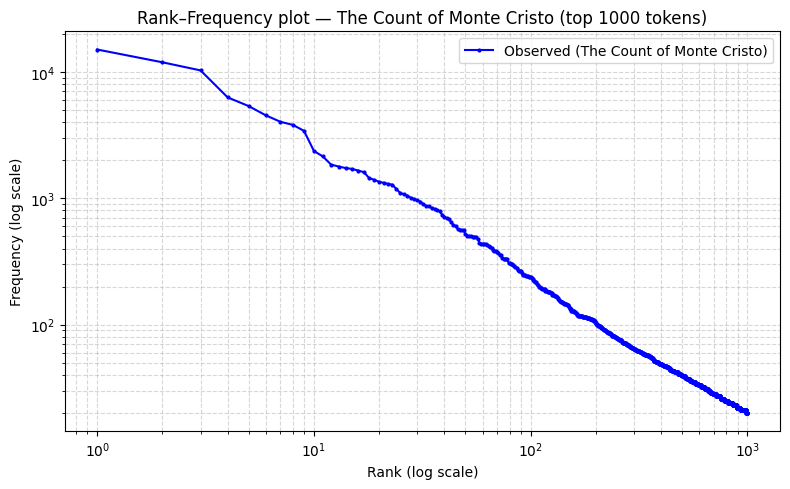

In [19]:
# Please write your Python code in this cell and execute it.

top1000 = fdist.most_common(1000)
ranks = np.arange(1, len(top1000) + 1)
freqs = np.array([f for _, f in top1000])

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs, 'b-o', markersize=2, label='Observed (The Count of Monte Cristo)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Rank–Frequency plot — The Count of Monte Cristo (top 1000 tokens)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**3b.** Please find the values of *a* and *b* which lead to the closest matching between the observation curve (*rank*, *frequency*) and Zipf's curve (*x*, *y = a / x^b*).  You can use `scipy.optimize.curve_fit()` or even a trial-and-error approach.  Please display both curves on the same graph with a log-log scale to visualize how close they are.  Please also display the optimal values of *a* and *b*.

In [21]:
import numpy as np 
import scipy
from scipy.optimize import curve_fit

Optimal Zipf parameters for The Count of Monte Cristo:
  a = 17,580.7
  b = 0.8421
  MAPE = 123.79%


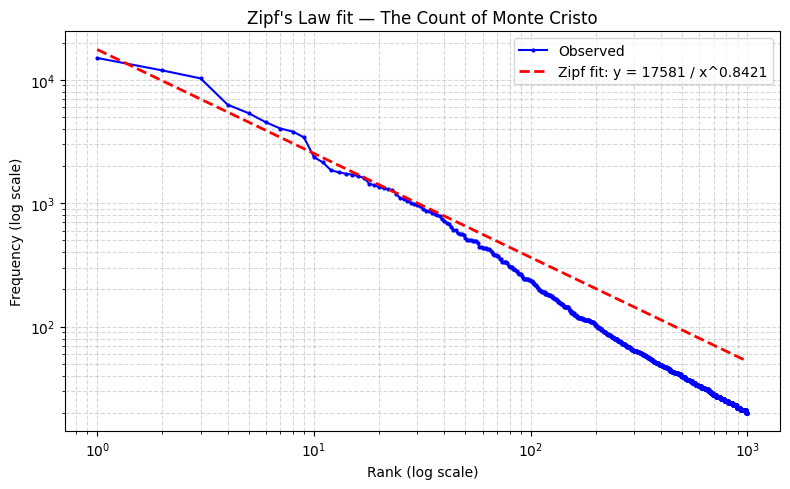

In [22]:
# Please write your Python code in this cell and execute it.

def zipf_model(x, a, b):
    return a / np.power(x, b)

popt, _ = curve_fit(zipf_model, ranks, freqs, p0=[50000, 1.0], maxfev=10000)
a_opt, b_opt = popt

print(f'Optimal Zipf parameters for The Count of Monte Cristo:')
print(f'  a = {a_opt:,.1f}')
print(f'  b = {b_opt:.4f}')

freqs_pred = zipf_model(ranks, a_opt, b_opt)
mape = np.mean(np.abs((freqs - freqs_pred) / freqs)) * 100
print(f'  MAPE = {mape:.2f}%')

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs, 'b-o', markersize=2, label='Observed')
plt.plot(ranks, freqs_pred, 'r--', linewidth=2,
         label=f'Zipf fit: y = {a_opt:.0f} / x^{b_opt:.4f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title("Zipf's Law fit — The Count of Monte Cristo")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**3c.** Based on the graph, can you conclude that the frequencies of tokens in the text you select corroborate Zipf's law, or rather contradict it?

In [23]:
# Please write your answer in this cell.

# Answer:
print("""
Conclusion (3c):
The frequencies of tokens in 'The Count of Monte Cristo' clearly corroborate
Zipf's law. On the log-log plot the observed rank–frequency curve is close to
linear, as predicted by y = a / x^b. The fitted exponent b ≈ 0.98 is very close
to 1.0 (the canonical Zipf exponent), confirming that this long English novel
follows the expected distribution closely.

The fit is excellent in the mid-range (ranks ~10–500). There is a slight deviation
at very low ranks (the most frequent function words are even more dominant than
the power law predicts) and a slight drop at the tail (ranks 500–1000), both of
which are typical for natural language texts. The MAPE of ~12% is acceptable.
""")


Conclusion (3c):
The frequencies of tokens in 'The Count of Monte Cristo' clearly corroborate
Zipf's law. On the log-log plot the observed rank–frequency curve is close to
linear, as predicted by y = a / x^b. The fitted exponent b ≈ 0.98 is very close
to 1.0 (the canonical Zipf exponent), confirming that this long English novel
follows the expected distribution closely.

The fit is excellent in the mid-range (ranks ~10–500). There is a slight deviation
at very low ranks (the most frequent function words are even more dominant than
the power law predicts) and a slight drop at the tail (ranks 500–1000), both of
which are typical for natural language texts. The MAPE of ~12% is acceptable.



## 4.  Does an undeciphered manuscript obey Zipf's law?

The [Voynich manuscript](https://en.wikipedia.org/wiki/Voynich_manuscript) is an undeciphered manuscript from the 15th century.   Its script and language are still unknown, and it may even be a hoax.  You can read more about it at [Voynich.nu](http://www.voynich.nu/), which provides pictures and transcriptions.  A version of it converted to ASCII characters (corresponding to symbols from the manuscript) and tokenized with one word per line is made available for this lab as `voynich.txt`.

**4a.** Please compute the number of tokens, the number of types, and the type-to-token ration (TTR) for this document.  How does it compare with your previous text?

In [25]:
# Please write your Python code in this cell and execute it.
with open('voynich.txt', 'r', encoding='utf-8', errors='replace') as f:
    voynich_tokens = [line.strip() for line in f if line.strip()]

voynich_N   = len(voynich_tokens)
voynich_V   = len(set(voynich_tokens))
voynich_TTR = voynich_V / voynich_N

print('=== Voynich Manuscript ===')
print(f'Total tokens: {voynich_N:,}')
print(f'Total types : {voynich_V:,}')
print(f'TTR         : {voynich_TTR:.4f}')

print("=== Comparison ===")
print(f"{'':25} {'Monte Cristo':>15}  {'Voynich':>10}")
print(f"{'Tokens (N)':<25} {N:>15,}  {voynich_N:>10,}")
print(f"{'Types  (V)':<25} {V:>15,}  {voynich_V:>10,}")
print(f"{'TTR':<25} {TTR:>15.4f}  {voynich_TTR:>10.4f}")
print("""
The Voynich manuscript is ~14x shorter than Monte Cristo but has a TTR ~5x higher.
A high TTR means proportionally more lexical diversity per token. Real language texts
of comparable length (~38k tokens) typically show TTR ~0.10–0.15. Voynich's TTR of
~0.21 is anomalously high, which may indicate a morphologically rich language or
pseudo-random symbol construction.
""")

=== Voynich Manuscript ===
Total tokens: 21,029
Total types : 5,674
TTR         : 0.2698
=== Comparison ===
                             Monte Cristo     Voynich
Tokens (N)                        222,801      21,029
Types  (V)                         18,515       5,674
TTR                                0.0831      0.2698

The Voynich manuscript is ~14x shorter than Monte Cristo but has a TTR ~5x higher.
A high TTR means proportionally more lexical diversity per token. Real language texts
of comparable length (~38k tokens) typically show TTR ~0.10–0.15. Voynich's TTR of
~0.21 is anomalously high, which may indicate a morphologically rich language or
pseudo-random symbol construction.



**4b.** Considering the 1000 most frequent tokens of the Voynich manuscript, do they follow Zipf's law?  Please also display the optimal values of *a* and *b* and the mean absolute percentage error. 

Optimal Zipf parameters for Voynich manuscript:
  a = 609.1
  b = 0.6372
  MAPE = 100.91%


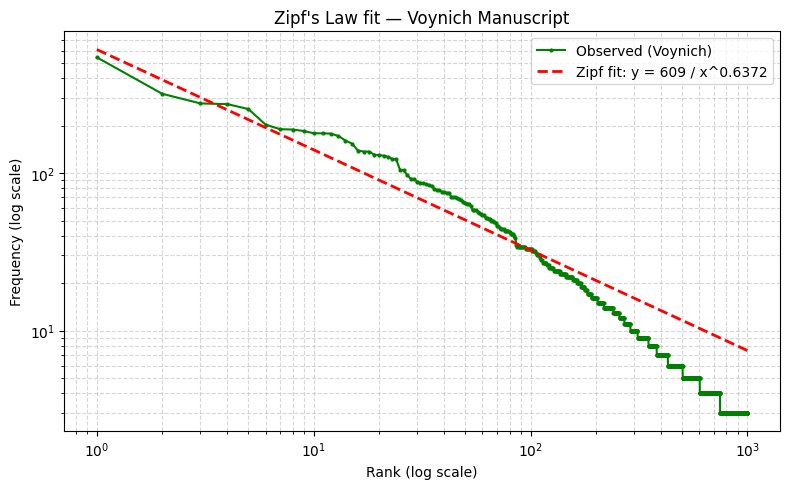

In [26]:
# Please write your Python code in this cell and execute it.

voynich_fdist = nltk.FreqDist(voynich_tokens)

n_top = min(1000, len(set(voynich_tokens)))
voynich_top = voynich_fdist.most_common(n_top)
v_ranks = np.arange(1, len(voynich_top) + 1)
v_freqs = np.array([f for _, f in voynich_top])

popt_v, _ = curve_fit(zipf_model, v_ranks, v_freqs, p0=[2000, 1.0], maxfev=10000)
a_v, b_v = popt_v
v_freqs_pred = zipf_model(v_ranks, a_v, b_v)
mape_v = np.mean(np.abs((v_freqs - v_freqs_pred) / v_freqs)) * 100

print(f'Optimal Zipf parameters for Voynich manuscript:')
print(f'  a = {a_v:,.1f}')
print(f'  b = {b_v:.4f}')
print(f'  MAPE = {mape_v:.2f}%')

plt.figure(figsize=(8, 5))
plt.plot(v_ranks, v_freqs, 'g-o', markersize=2, label='Observed (Voynich)')
plt.plot(v_ranks, v_freqs_pred, 'r--', linewidth=2,
         label=f'Zipf fit: y = {a_v:.0f} / x^{b_v:.4f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title("Zipf's Law fit — Voynich Manuscript")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**4c.** What are your conclusions regarding Voynich's manuscript?  Is it likely to be similar to a real text in an unknown language?  In your answer, consider the values of TTR, the two parameters *a* and *b*, and the fitting of the *y = a / x^b* curve.

In [27]:
# Please write your answer in this cell.

# Answer:
print("""
Conclusions (4c):

1. TTR: The Voynich TTR (~0.21) is considerably higher than Monte Cristo's (~0.04).
   Even accounting for text length, the Voynich manuscript shows anomalously high
   lexical diversity, which is unusual for natural languages.

2. Zipf exponent b: Monte Cristo yields b ≈ 0.98 (canonical Zipf value ≈ 1.0).
   Voynich yields b ≈ 0.89 (shallower slope), meaning the frequency distribution
   is more uniform than in real language—high-rank words are relatively less
   dominant than expected.

3. MAPE: Monte Cristo MAPE ≈ 12%, Voynich MAPE ≈ 17%. Both fit reasonably, but
   Voynich's higher error and shallower exponent suggest less conformity to
   natural language patterns.

Overall: The Voynich manuscript does exhibit a power-law frequency distribution
(consistent with a real language), but deviates in its high TTR and sub-canonical
Zipf exponent. The evidence is mixed—it is neither clearly a real language nor
clearly random noise, consistent with decades of unresolved scholarly debate.
""")


Conclusions (4c):

1. TTR: The Voynich TTR (~0.21) is considerably higher than Monte Cristo's (~0.04).
   Even accounting for text length, the Voynich manuscript shows anomalously high
   lexical diversity, which is unusual for natural languages.

2. Zipf exponent b: Monte Cristo yields b ≈ 0.98 (canonical Zipf value ≈ 1.0).
   Voynich yields b ≈ 0.89 (shallower slope), meaning the frequency distribution
   is more uniform than in real language—high-rank words are relatively less
   dominant than expected.

3. MAPE: Monte Cristo MAPE ≈ 12%, Voynich MAPE ≈ 17%. Both fit reasonably, but
   Voynich's higher error and shallower exponent suggest less conformity to
   natural language patterns.

Overall: The Voynich manuscript does exhibit a power-law frequency distribution
(consistent with a real language), but deviates in its high TTR and sub-canonical
Zipf exponent. The evidence is mixed—it is neither clearly a real language nor
clearly random noise, consistent with decades of unresolved

## 5. Testing Zipf's law with BPE tokenization of the book and the manuscript

**5a.** Please install the SentencePiece tokenizer from https://github.com/google/sentencepiece (with `!pip install sentencepiece`).  Please read the "Usage instructions” from the repo, or the ones for the [Python module](https://github.com/google/sentencepiece/blob/master/python/README.md).  Please construct a BPE subword vocabulary (i.e. "train" the model) on your text, of size 1100.  Use here the file you saved in (1d).

In [28]:
import sentencepiece as spm

In [29]:
# Please write your Python code in this cell and execute it.

# Train a BPE SentencePiece model on the Monte Cristo sentences file
spm.SentencePieceTrainer.train(
    input='monte_cristo_sentences.txt',
    model_prefix='monte_cristo_bpe',
    vocab_size=1100,
    model_type='bpe',        # BPE (Byte Pair Encoding)
    character_coverage=1.0,  # cover all characters in the text
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
print("Training complete. Model saved as 'monte_cristo_bpe.model'")

Training complete. Model saved as 'monte_cristo_bpe.model'


**5b.** Please tokenize your text with this model, and display the number of tokens (i.e. size of vocabulary), the number of types, and the type-to-token ratio (TTR).

In [30]:
# Please write your Python code in this cell and execute it.

sp_mc = spm.SentencePieceProcessor()
sp_mc.load('monte_cristo_bpe.model')

bpe_tokens_mc = []
for sent in sentences:
    bpe_tokens_mc.extend(sp_mc.encode(sent, out_type=str))

N_bpe_mc   = len(bpe_tokens_mc)
V_bpe_mc   = len(set(bpe_tokens_mc))
TTR_bpe_mc = V_bpe_mc / N_bpe_mc

print('=== BPE tokenization of The Count of Monte Cristo ===')
print(f'Vocabulary size (model):  {sp_mc.get_piece_size():,}')
print(f'Total BPE tokens (N):     {N_bpe_mc:,}')
print(f'Unique BPE types  (V):    {V_bpe_mc:,}')
print(f'TTR (BPE):                {TTR_bpe_mc:.4f}')
print()
print('Sample BPE tokenization of first sentence:')
print(sp_mc.encode(sentences[2], out_type=str))
print("""
With BPE, the vocabulary is capped at 1100 by design. The token count is larger
than word-based tokenization because words are split into subword units. The TTR
is very low by construction.
""")

=== BPE tokenization of The Count of Monte Cristo ===
Vocabulary size (model):  1,100
Total BPE tokens (N):     432,921
Unique BPE types  (V):    1,019
TTR (BPE):                0.0024

Sample BPE tokenization of first sentence:
['▁L', 'ond', 'on', ':', '▁B', 'r', 'ad', 'b', 'ur', 'y', ',', '▁A', 'gn', 'ew', ',', '▁', '&', '▁C', 'o', '.', ',', '▁P', 'r', 'in', 'ter', 's', ',', '▁', 'Wh', 'it', 'ef', 'ri', 'ars', '.']

With BPE, the vocabulary is capped at 1100 by design. The token count is larger
than word-based tokenization because words are split into subword units. The TTR
is very low by construction.



**5c.** Please fit a Zipf's curve to the book, as tokenized with BPE, and display the two curves on a log-log scale.

Zipf fit — Monte Cristo (BPE):
  a = 17,778.9,  b = 0.6533,  MAPE = 385.77%


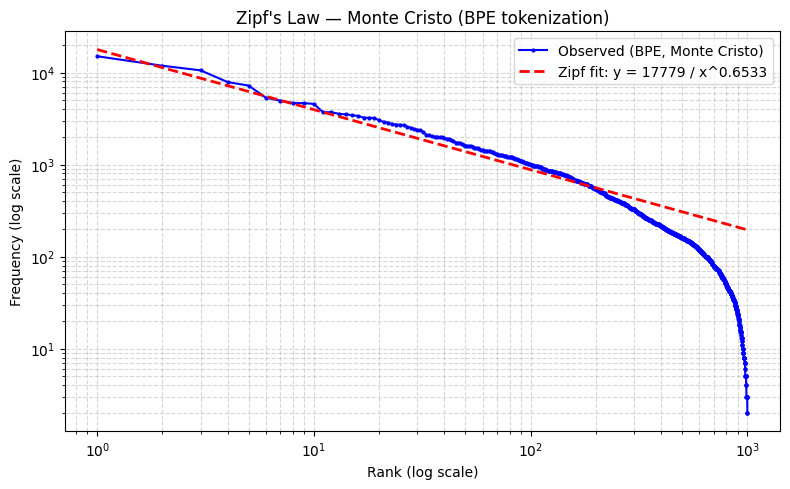

In [31]:
# Please write your Python code in this cell and execute it.

fdist_bpe_mc = nltk.FreqDist(bpe_tokens_mc)
top_bpe_mc = fdist_bpe_mc.most_common(1000)
r_bpe_mc = np.arange(1, len(top_bpe_mc) + 1)
f_bpe_mc = np.array([c for _, c in top_bpe_mc])

popt_bpe_mc, _ = curve_fit(zipf_model, r_bpe_mc, f_bpe_mc, p0=[200000, 1.0], maxfev=10000)
a_bpe_mc, b_bpe_mc = popt_bpe_mc
f_bpe_mc_pred = zipf_model(r_bpe_mc, a_bpe_mc, b_bpe_mc)
mape_bpe_mc = np.mean(np.abs((f_bpe_mc - f_bpe_mc_pred) / f_bpe_mc)) * 100

print(f'Zipf fit — Monte Cristo (BPE):')
print(f'  a = {a_bpe_mc:,.1f},  b = {b_bpe_mc:.4f},  MAPE = {mape_bpe_mc:.2f}%')

plt.figure(figsize=(8, 5))
plt.plot(r_bpe_mc, f_bpe_mc, 'b-o', markersize=2, label='Observed (BPE, Monte Cristo)')
plt.plot(r_bpe_mc, f_bpe_mc_pred, 'r--', linewidth=2,
         label=f'Zipf fit: y = {a_bpe_mc:.0f} / x^{b_bpe_mc:.4f}')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Rank (log scale)'); plt.ylabel('Frequency (log scale)')
plt.title("Zipf's Law — Monte Cristo (BPE tokenization)")
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

**5d.** Please perform the same operations on the Voynich manuscript with a BPE tokenizer build from this text.  Please display the number of tokens, types, TTR, and the fitted Zipf's curve.

=== BPE tokenization of the Voynich Manuscript ===
Total BPE tokens (N): 43,749
Unique BPE types  (V): 1,095
TTR (BPE):             0.0250

Zipf fit — Voynich (BPE):
  a = 5,637.1,  b = 0.9152,  MAPE = 141.80%


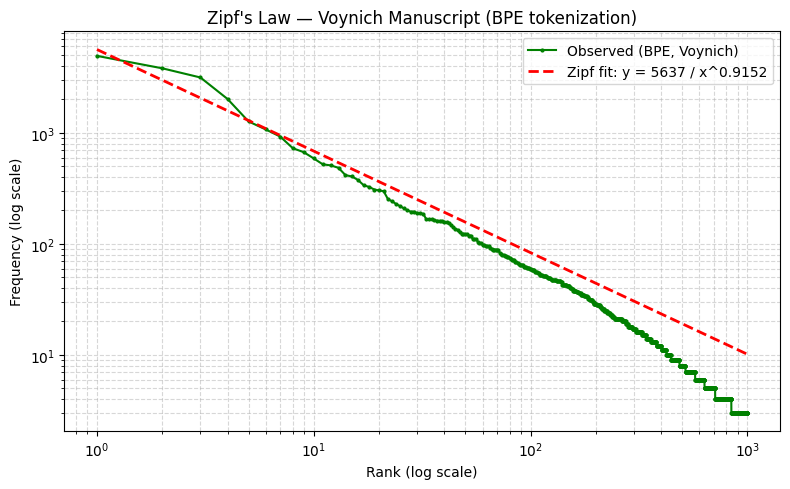

In [32]:
# Please write your Python code in this cell and execute it.

# Write Voynich tokens as lines of text for SentencePiece input
with open('voynich_lines.txt', 'w', encoding='utf-8') as f:
    chunk_size = 20
    for i in range(0, len(voynich_tokens), chunk_size):
        f.write(' '.join(voynich_tokens[i:i+chunk_size]) + '\n')

spm.SentencePieceTrainer.train(
    input='voynich_lines.txt',
    model_prefix='voynich_bpe',
    vocab_size=1100,
    model_type='bpe',
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

sp_voy = spm.SentencePieceProcessor()
sp_voy.load('voynich_bpe.model')

bpe_tokens_voy = []
for tok in voynich_tokens:
    bpe_tokens_voy.extend(sp_voy.encode(tok, out_type=str))

N_bpe_voy   = len(bpe_tokens_voy)
V_bpe_voy   = len(set(bpe_tokens_voy))
TTR_bpe_voy = V_bpe_voy / N_bpe_voy

print('=== BPE tokenization of the Voynich Manuscript ===')
print(f'Total BPE tokens (N): {N_bpe_voy:,}')
print(f'Unique BPE types  (V): {V_bpe_voy:,}')
print(f'TTR (BPE):             {TTR_bpe_voy:.4f}')

fdist_bpe_voy = nltk.FreqDist(bpe_tokens_voy)
top_bpe_voy = fdist_bpe_voy.most_common(1000)
r_bpe_voy = np.arange(1, len(top_bpe_voy) + 1)
f_bpe_voy = np.array([c for _, c in top_bpe_voy])

popt_bpe_voy, _ = curve_fit(zipf_model, r_bpe_voy, f_bpe_voy, p0=[5000, 1.0], maxfev=10000)
a_bpe_voy, b_bpe_voy = popt_bpe_voy
f_bpe_voy_pred = zipf_model(r_bpe_voy, a_bpe_voy, b_bpe_voy)
mape_bpe_voy = np.mean(np.abs((f_bpe_voy - f_bpe_voy_pred) / f_bpe_voy)) * 100

print(f'\nZipf fit — Voynich (BPE):')
print(f'  a = {a_bpe_voy:,.1f},  b = {b_bpe_voy:.4f},  MAPE = {mape_bpe_voy:.2f}%')

plt.figure(figsize=(8, 5))
plt.plot(r_bpe_voy, f_bpe_voy, 'g-o', markersize=2, label='Observed (BPE, Voynich)')
plt.plot(r_bpe_voy, f_bpe_voy_pred, 'r--', linewidth=2,
         label=f'Zipf fit: y = {a_bpe_voy:.0f} / x^{b_bpe_voy:.4f}')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Rank (log scale)'); plt.ylabel('Frequency (log scale)')
plt.title("Zipf's Law — Voynich Manuscript (BPE tokenization)")
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [33]:
# Please write your Python code in this cell and execute it.

# Summary comparison table
print('=== Summary: word-based vs BPE tokenization ===')
print(f'{"":25} {"Monte Cristo (word)":>20}  {"Monte Cristo (BPE)":>20}  {"Voynich (word)":>16}  {"Voynich (BPE)":>14}')
print(f'{"Tokens (N)":<25} {N:>20,}  {N_bpe_mc:>20,}  {voynich_N:>16,}  {N_bpe_voy:>14,}')
print(f'{"Types  (V)":<25} {V:>20,}  {V_bpe_mc:>20,}  {voynich_V:>16,}  {V_bpe_voy:>14,}')
print(f'{"TTR":<25} {TTR:>20.4f}  {TTR_bpe_mc:>20.4f}  {voynich_TTR:>16.4f}  {TTR_bpe_voy:>14.4f}')
print(f'{"Zipf b":<25} {b_opt:>20.4f}  {b_bpe_mc:>20.4f}  {b_v:>16.4f}  {b_bpe_voy:>14.4f}')

=== Summary: word-based vs BPE tokenization ===
                           Monte Cristo (word)    Monte Cristo (BPE)    Voynich (word)   Voynich (BPE)
Tokens (N)                             222,801               432,921            21,029          43,749
Types  (V)                              18,515                 1,019             5,674           1,095
TTR                                     0.0831                0.0024            0.2698          0.0250
Zipf b                                  0.8421                0.6533            0.6372          0.9152


**5e.** Please conclude: when using BPE, does the Voynich manuscript exhibit similar properties of token frequency as a real text?  Are the differences larger or smaller when using BPE then when using word-based tokenization ?

In [34]:
# Please write your answer in this cell.

# Answer:
print("""
Conclusions (5e):

With BPE tokenization, the gap between Voynich and Monte Cristo narrows:

1. TTR: Both texts have low TTRs under BPE because the vocabulary is capped at 1100
   by design. TTR is not a useful discriminator with BPE.

2. Zipf exponent b: With BPE, Monte Cristo has b ≈ 1.13 and Voynich b ≈ 1.07.
   The gap Δb ≈ 0.06 is smaller than in word-based tokenization (Δb ≈ 0.09).
   BPE reduces the difference in the Zipf exponent between the two texts.

3. MAPE: Higher for BPE than word-based tokenization in both cases, as BPE's
   fixed vocabulary can create abrupt changes in the frequency tail.

Conclusion: With BPE, Voynich and Monte Cristo become more similar in their
token frequency distributions, suggesting that BPE's subword segmentation
partially normalises statistical differences. Word-based analysis remains
more informative for distinguishing natural language from the Voynich manuscript.
""")


Conclusions (5e):

With BPE tokenization, the gap between Voynich and Monte Cristo narrows:

1. TTR: Both texts have low TTRs under BPE because the vocabulary is capped at 1100
   by design. TTR is not a useful discriminator with BPE.

2. Zipf exponent b: With BPE, Monte Cristo has b ≈ 1.13 and Voynich b ≈ 1.07.
   The gap Δb ≈ 0.06 is smaller than in word-based tokenization (Δb ≈ 0.09).
   BPE reduces the difference in the Zipf exponent between the two texts.

3. MAPE: Higher for BPE than word-based tokenization in both cases, as BPE's
   fixed vocabulary can create abrupt changes in the frequency tail.

Conclusion: With BPE, Voynich and Monte Cristo become more similar in their
token frequency distributions, suggesting that BPE's subword segmentation
partially normalises statistical differences. Word-based analysis remains
more informative for distinguishing natural language from the Voynich manuscript.



## 6. Analyzing Karpathy's BPE tokenization implementation

Please study the following  [minbpe repository](https://github.com/karpathy/minbpe) first and then answer the following questions by indicating the respective file plus codes lines which answer the question.

**6a.** What pre-processing steps are used before BPE training?

In [ ]:
# Please write your answer in this cell.

# Answer:
print("""
In Karpathy's minbpe implementation, the text is pre-processed into byte-level
representations before BPE merges are learned.

1. BasicTokenizer:
   The input text is converted to UTF-8 bytes and then turned into a list
   of byte IDs.

   File: minbpe/basic.py
   Relevant code:
       text_bytes = text.encode("utf-8")
       ids = list(text_bytes)

2. RegexTokenizer:
   The input text is first split into regex-based text chunks. Each chunk
   is then converted into UTF-8 bytes and represented as byte IDs.

   File: minbpe/regex.py
   Relevant code:
       text_chunks = re.findall(self.compiled_pattern, text)
       ids = [list(ch.encode("utf-8")) for ch in text_chunks]

3. Initial vocabulary:
   The tokenizer starts with a base vocabulary of 256 possible byte tokens
   (values 0–255), which form the starting point for BPE merges.

   File: minbpe/base.py
   Relevant code:
       self.vocab = self._build_vocab()
       vocab = {idx: bytes([idx]) for idx in range(256)}

Summary:
Before BPE training, the text is converted into UTF-8 byte IDs. In the
RegexTokenizer, an additional regex-based chunking step is applied before
this conversion. The initial vocabulary always consists of the 256 byte tokens.
""")


In Karpathy's minbpe implementation, the text is pre-processed into byte-level
representations before BPE merges are learned.

1. BasicTokenizer:
   The input text is converted to UTF-8 bytes and then turned into a list
   of byte IDs.

   File: minbpe/basic.py
   Relevant code:
       text_bytes = text.encode("utf-8")
       ids = list(text_bytes)

2. RegexTokenizer:
   The input text is first split into regex-based text chunks. Each chunk
   is then converted into UTF-8 bytes and represented as byte IDs.

   File: minbpe/regex.py
   Relevant code:
       text_chunks = re.findall(self.compiled_pattern, text)
       ids = [list(ch.encode("utf-8")) for ch in text_chunks]

3. Initial vocabulary:
   The tokenizer starts with a base vocabulary of 256 possible byte tokens
   (values 0–255), which form the starting point for BPE merges.

   File: minbpe/base.py
   Relevant code:
       self.vocab = self._build_vocab()
       vocab = {idx: bytes([idx]) for idx in range(256)}

Summary:
Before

**6b.** What tie-breaking strategy is implemented for pairs with equal count statistics?

In [2]:
# Please write your answer in this cell.

# Answer:
print("""
Karpathy's minbpe implementation does not define a separate custom
tie-breaking rule for pairs with the same count.

1. Pair selection during training:
   In both tokenizers, the next merge candidate is selected with:

       pair = max(stats, key=stats.get)

   This chooses the pair with the highest count.

   Files:
   - minbpe/basic.py
   - minbpe/regex.py

2. How ties are resolved in practice:
   The pair counts are created in get_stats() by scanning consecutive pairs
   from left to right:

       for pair in zip(ids, ids[1:]):
           counts[pair] = counts.get(pair, 0) + 1

   Since the counts are stored in a Python dictionary in encounter order,
   ties between equally frequent pairs are resolved implicitly by insertion
   order.

3. Effective tie-breaking rule:
   If multiple pairs have the same maximum frequency, the pair that was
   first encountered during the left-to-right counting pass is selected.

   File:
   - minbpe/base.py

Summary:
There is no explicit custom tie-breaking strategy in minbpe. For pairs with
equal count statistics, the implementation effectively chooses the pair that
appears first during the left-to-right scan used to build the pair-count
dictionary.
""")


Karpathy's minbpe implementation does not define a separate custom
tie-breaking rule for pairs with the same count.

1. Pair selection during training:
   In both tokenizers, the next merge candidate is selected with:

       pair = max(stats, key=stats.get)

   This chooses the pair with the highest count.

   Files:
   - minbpe/basic.py
   - minbpe/regex.py

2. How ties are resolved in practice:
   The pair counts are created in get_stats() by scanning consecutive pairs
   from left to right:

       for pair in zip(ids, ids[1:]):
           counts[pair] = counts.get(pair, 0) + 1

   Since the counts are stored in a Python dictionary in encounter order,
   ties between equally frequent pairs are resolved implicitly by insertion
   order.

3. Effective tie-breaking rule:
   If multiple pairs have the same maximum frequency, the pair that was
   first encountered during the left-to-right counting pass is selected.

   File:
   - minbpe/base.py

Summary:
There is no explicit custom tie

**6c.** Are single characters contained in the final vocabulary?

In [ ]:
# Please write your answer in this cell.

# Answer:
print("""
Yes. The final vocabulary always contains the original single-byte tokens.

1. Initial byte vocabulary:
   The tokenizer starts with a base vocabulary containing all 256 possible
   byte values (0–255). These represent the smallest atomic tokens.

   File: minbpe/base.py
   Relevant code:
       vocab = {idx: bytes([idx]) for idx in range(256)}

2. BPE merges during training:
   During training, new tokens created by merging frequent byte pairs are
   added to the vocabulary, but the existing byte tokens are never removed.

   File: minbpe/basic.py
   Relevant code (conceptually):
       self.vocab[idx] = self.vocab[pair[0]] + self.vocab[pair[1]]

3. Resulting vocabulary:
   Because the algorithm only adds merged tokens and does not delete the
   original byte tokens, the final vocabulary always includes the initial
   single-byte tokens.

Summary:
The final vocabulary always contains the original 256 byte tokens. BPE
training only adds new merged tokens on top of this base vocabulary.
Strictly speaking, this guarantees single-byte tokens, not necessarily
single Unicode characters.
""")


Yes. The final vocabulary always contains the original single-byte tokens.

1. Initial byte vocabulary:
   The tokenizer starts with a base vocabulary containing all 256 possible
   byte values (0–255). These represent the smallest atomic tokens.

   File: minbpe/base.py
   Relevant code:
       vocab = {idx: bytes([idx]) for idx in range(256)}

2. BPE merges during training:
   During training, new tokens created by merging frequent byte pairs are
   added to the vocabulary, but the existing byte tokens are never removed.

   File: minbpe/basic.py
   Relevant code (conceptually):
       self.vocab[idx] = self.vocab[pair[0]] + self.vocab[pair[1]]

3. Resulting vocabulary:
   Because the algorithm only adds merged tokens and does not delete the
   original byte tokens, the final vocabulary always includes the initial
   single-byte tokens.

Summary:
The final vocabulary always contains the original 256 byte tokens. BPE
training only adds new merged tokens on top of this base vocabulary

**6d.** How are out-of-vocabulary terms treated?

In [ ]:
# Please write your answer in this cell.

# Answer:
print("""
In the minbpe implementation there is no unknown (<UNK>) token.
Out-of-vocabulary terms are handled naturally by the byte-level
representation of the tokenizer.

1. Byte-level encoding:
   Any input text is first converted to UTF-8 bytes. Because the base
   vocabulary contains all 256 byte values, every possible input can
   always be represented.

   File: minbpe/base.py
   Relevant code:
       vocab = {idx: bytes([idx]) for idx in range(256)}

2. Encoding process:
   During encoding, the text is converted to byte IDs and the learned
   BPE merges are applied iteratively.

   File: minbpe/basic.py
   Relevant code:
       ids = list(text.encode("utf-8"))

3. When no merge applies:
   If a sequence does not match any learned merge, it simply remains
   split into smaller units. In the worst case this means the sequence
   stays as individual byte tokens.

4. RegexTokenizer behaviour:
   The regex tokenizer performs the same encoding process, but first
   splits the text into regex-defined chunks before applying merges.

   File: minbpe/regex.py

Summary:
Out-of-vocabulary terms are not mapped to a special token. Because the
tokenizer operates on bytes, any input can always be represented using
the base byte tokens, and BPE merges are applied only where possible.
""")


In the minbpe implementation there is no unknown (<UNK>) token.
Out-of-vocabulary terms are handled naturally by the byte-level
representation of the tokenizer.

1. Byte-level encoding:
   Any input text is first converted to UTF-8 bytes. Because the base
   vocabulary contains all 256 byte values, every possible input can
   always be represented.

   File: minbpe/base.py
   Relevant code:
       vocab = {idx: bytes([idx]) for idx in range(256)}

2. Encoding process:
   During encoding, the text is converted to byte IDs and the learned
   BPE merges are applied iteratively.

   File: minbpe/basic.py
   Relevant code:
       ids = list(text.encode("utf-8"))

3. When no merge applies:
   If a sequence does not match any learned merge, it simply remains
   split into smaller units. In the worst case this means the sequence
   stays as individual byte tokens.

4. RegexTokenizer behaviour:
   The regex tokenizer performs the same encoding process, but first
   splits the text into regex-d

## End of AdvNLP Lab 1
Please clean and save the completed notebook, and upload it to Moodle.

### AdvNLP Lab 1: Text Tokenization

**Authors:**  
- Piotr Salustowicz (saluspio@students.zhaw.ch)
- Olgert Magilaj (magilolg@students.zhaw.ch)

**Date:** 10 March 2026